# Forest Cover Type Classification
## Task 3: Multi-class Classification Project

**Dataset:** UCI Covertype Dataset  
**Objective:** Predict forest cover type based on cartographic and environmental features


**Covered Topics:**
- Multi-class classification
- Tree-based modeling (Random Forest, XGBoost)
- Hyperparameter tuning
- Model comparison

---

In [1]:
!pip install xgboost -q

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)
import xgboost as xgb
from sklearn.datasets import fetch_covtype
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Load the Dataset

The Covertype dataset contains cartographic variables for 30m x 30m patches of forest in Colorado, USA.

In [3]:
covertype = fetch_covtype(as_frame=True)
df = covertype.frame
print(f"Dataset shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")
print(f"Target classes: {len(df['Cover_Type'].unique())}")
print(f"Total samples: {len(df):,}")
df.head(10)

Dataset shape: (581012, 55)
Features: 54
Target classes: 7
Total samples: 581,012


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
5,2579.0,132.0,6.0,300.0,-15.0,67.0,230.0,237.0,140.0,6031.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
6,2606.0,45.0,7.0,270.0,5.0,633.0,222.0,225.0,138.0,6256.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
7,2605.0,49.0,4.0,234.0,7.0,573.0,222.0,230.0,144.0,6228.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
8,2617.0,45.0,9.0,240.0,56.0,666.0,223.0,221.0,133.0,6244.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
9,2612.0,59.0,10.0,247.0,11.0,636.0,228.0,219.0,124.0,6230.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


## Step 2: Exploratory Data Analysis

In [4]:
print("Dataset Info:")
print("="*80)
df.info()

missing = df.isnull().sum().sum()
print(f"Missing values: {missing}")
if missing == 0:
    print("No missing values found!")

print("\nTarget Variable Distribution:")
print(df['Cover_Type'].value_counts().sort_index())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_A

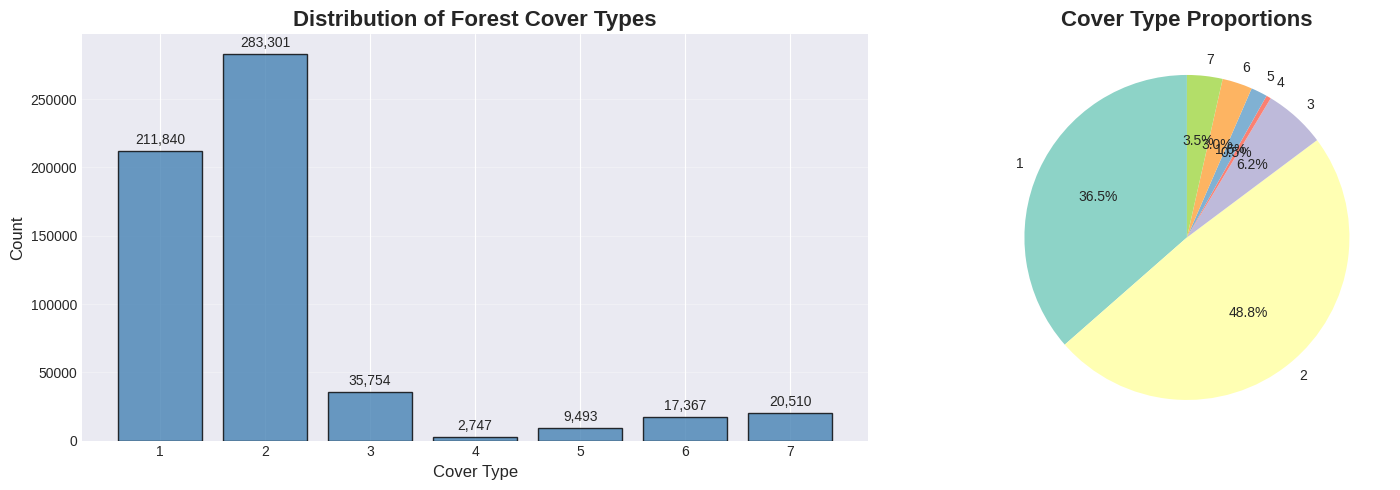


Note: Class imbalance is present - some cover types are more common than others.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

target_counts = df['Cover_Type'].value_counts().sort_index()
axes[0].bar(target_counts.index, target_counts.values, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Distribution of Forest Cover Types', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Cover Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(target_counts.values):
    axes[0].text(i+1, v + 5000, f'{v:,}', ha='center', fontsize=10)

colors = plt.cm.Set3(range(len(target_counts)))
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Cover Type Proportions', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: Class imbalance is present - some cover types are more common than others.")

In [6]:
print("Statistical Summary (first 10 continuous features):")
df.iloc[:, :10].describe()

Statistical Summary (first 10 continuous features):


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000


In [7]:
print("Feature Breakdown:")
print("\nContinuous Features (0-9):")
continuous_features = list(df.columns[:10])
for i, feat in enumerate(continuous_features, 1):
    print(f"  {i}. {feat}")

print("\n Wilderness Area (4 binary features): Columns 10-13")
print("   - One-hot encoded categorical feature")

print("\n Soil Type (40 binary features): Columns 14-53")
print("   - One-hot encoded categorical feature")

print("\n All categorical features are already one-hot encoded!")

Feature Breakdown:

Continuous Features (0-9):
  1. Elevation
  2. Aspect
  3. Slope
  4. Horizontal_Distance_To_Hydrology
  5. Vertical_Distance_To_Hydrology
  6. Horizontal_Distance_To_Roadways
  7. Hillshade_9am
  8. Hillshade_Noon
  9. Hillshade_3pm
  10. Horizontal_Distance_To_Fire_Points

 Wilderness Area (4 binary features): Columns 10-13
   - One-hot encoded categorical feature

 Soil Type (40 binary features): Columns 14-53
   - One-hot encoded categorical feature

 All categorical features are already one-hot encoded!


## Step 3: Data Preprocessing

In [8]:
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\n Splitting data (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nStratified split ensures balanced class distribution in train/test sets!")

Features shape: (581012, 54)
Target shape: (581012,)

 Splitting data (80% train, 20% test)...

Training set: (464809, 54)
Test set: (116203, 54)

Stratified split ensures balanced class distribution in train/test sets!


In [9]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

continuous_cols = X_train.columns[:10]
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("\nScaling complete!")
print(f"\n Scaled features: {list(continuous_cols)}")
print(f" Binary features (not scaled): Wilderness_Area and Soil_Type columns")


Scaling complete!

 Scaled features: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
 Binary features (not scaled): Wilderness_Area and Soil_Type columns


## Step 4: Train Random Forest Classifier

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("RANDOM FOREST RESULTS")
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"F1-Score (weighted): {rf_f1:.4f}")

print("\n Detailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy: 0.8891 (88.91%)
F1-Score (weighted): 0.8871

 Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.91      0.85      0.88     42368
           2       0.87      0.94      0.90     56661
           3       0.92      0.93      0.92      7151
           4       0.90      0.84      0.87       549
           5       0.97      0.39      0.56      1899
           6       0.91      0.79      0.85      3473
           7       0.98      0.87      0.92      4102

    accuracy                           0.89    116203
   macro avg       0.92      0.80      0.84    116203
weighted avg       0.89      0.89      0.89    116203



## Step 5: Train XGBoost Classifier

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train - 1)

y_pred_xgb = xgb_model.predict(X_test_scaled) + 1

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

print(" XGBOOST RESULTS")
print(f"Accuracy: {xgb_accuracy:.4f} ({xgb_accuracy*100:.2f}%)")
print(f"F1-Score (weighted): {xgb_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))

 XGBOOST RESULTS
Accuracy: 0.8572 (85.72%)
F1-Score (weighted): 0.8559

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.82      0.84     42368
           2       0.85      0.90      0.87     56661
           3       0.86      0.89      0.88      7151
           4       0.87      0.84      0.86       549
           5       0.90      0.51      0.65      1899
           6       0.82      0.70      0.76      3473
           7       0.94      0.90      0.92      4102

    accuracy                           0.86    116203
   macro avg       0.87      0.80      0.82    116203
weighted avg       0.86      0.86      0.86    116203



##  Step 6: Model Comparison

MODEL COMPARISON
        Model  Accuracy  F1-Score
Random Forest  0.889125  0.887081
      XGBoost  0.857181  0.855943

Best Model: Random Forest (Accuracy: 0.8891)


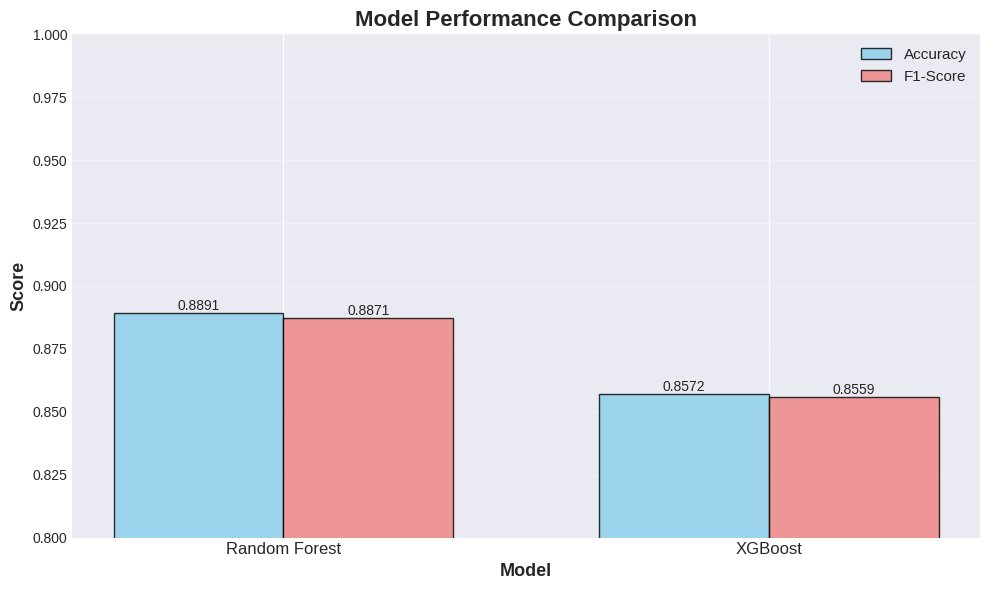

In [23]:
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'F1-Score': [rf_f1, xgb_f1]
})

print("MODEL COMPARISON")
print(comparison_df.to_string(index=False))

winner_idx = comparison_df['Accuracy'].idxmax()
winner = comparison_df.loc[winner_idx, 'Model']
winner_acc = comparison_df.loc[winner_idx, 'Accuracy']
print(f"\nBest Model: {winner} (Accuracy: {winner_acc:.4f})")

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x_pos - width/2, comparison_df['Accuracy'], width,
               label='Accuracy', alpha=0.8, color='skyblue', edgecolor='black')
bars2 = ax.bar(x_pos + width/2, comparison_df['F1-Score'], width,
               label='F1-Score', alpha=0.8, color='lightcoral', edgecolor='black')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison_df['Model'], fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim([0.80, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Confusion Matrix Visualization

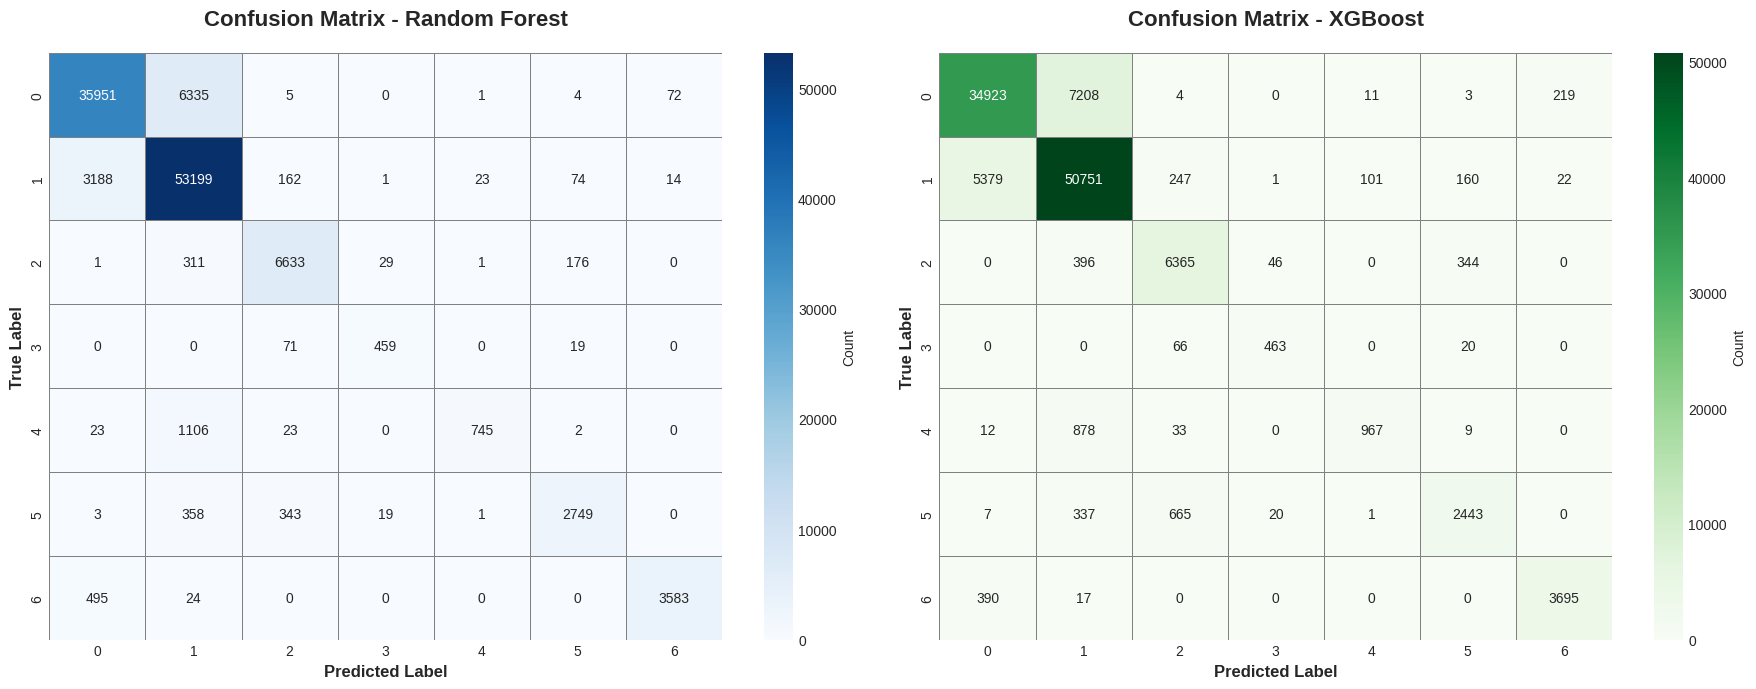


Confusion Matrix Interpretation:
  - Diagonal elements = Correct predictions
  - Off-diagonal elements = Misclassifications
  - Darker colors = Higher counts


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray')
axes[1].set_title('Confusion Matrix - XGBoost', fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("  - Diagonal elements = Correct predictions")
print("  - Off-diagonal elements = Misclassifications")
print("  - Darker colors = Higher counts")

## Step 8: Feature Importance Analysis

In [14]:
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features - Random Forest:")
print(feature_importance_rf.head(15).to_string(index=False))

print("\nTop 15 Most Important Features - XGBoost:")
print(feature_importance_xgb.head(15).to_string(index=False))

Top 15 Most Important Features - Random Forest:
                           feature  importance
                         Elevation    0.288950
   Horizontal_Distance_To_Roadways    0.099728
Horizontal_Distance_To_Fire_Points    0.088605
  Horizontal_Distance_To_Hydrology    0.046853
                 Wilderness_Area_3    0.045739
    Vertical_Distance_To_Hydrology    0.041524
                            Aspect    0.034895
                    Hillshade_Noon    0.033265
                     Hillshade_9am    0.030091
                     Hillshade_3pm    0.028120
                             Slope    0.024521
                      Soil_Type_21    0.023283
                       Soil_Type_9    0.020487
                       Soil_Type_3    0.018599
                 Wilderness_Area_2    0.017344

Top 15 Most Important Features - XGBoost:
          feature  importance
        Elevation    0.090053
      Soil_Type_2    0.076349
      Soil_Type_1    0.057326
Wilderness_Area_3    0.049324
Wildern

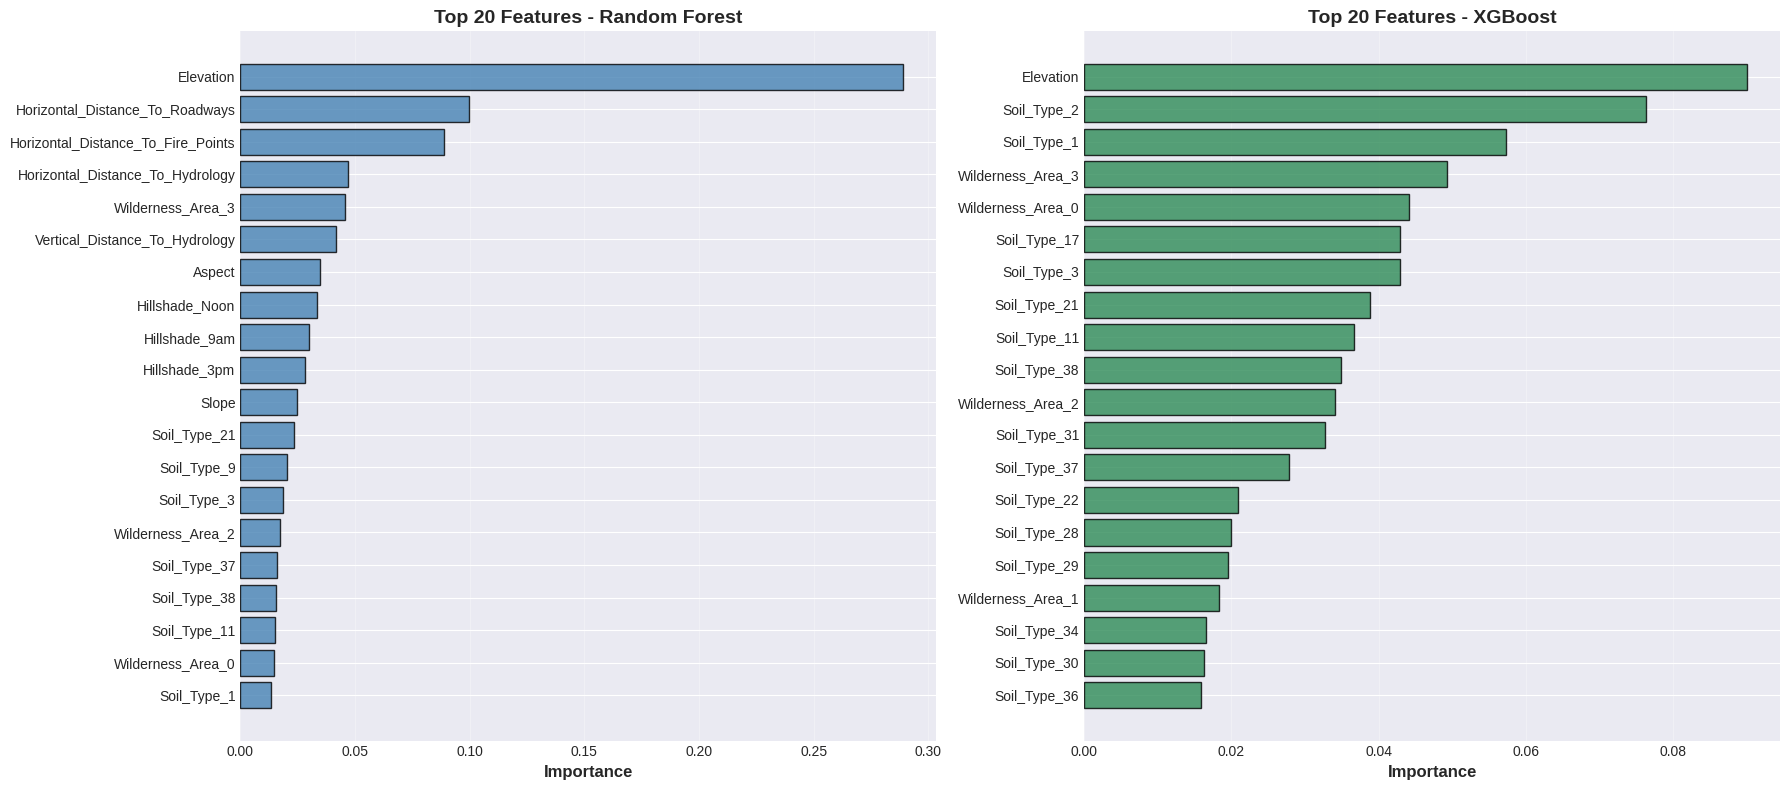


 Key Insights:
  - Random Forest top feature: Elevation
  - XGBoost top feature: Elevation


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top20_rf = feature_importance_rf.head(20)
axes[0].barh(range(len(top20_rf)), top20_rf['importance'],
             color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_yticks(range(len(top20_rf)))
axes[0].set_yticklabels(top20_rf['feature'], fontsize=10)
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Features - Random Forest', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top20_xgb = feature_importance_xgb.head(20)
axes[1].barh(range(len(top20_xgb)), top20_xgb['importance'],
             color='seagreen', alpha=0.8, edgecolor='black')
axes[1].set_yticks(range(len(top20_xgb)))
axes[1].set_yticklabels(top20_xgb['feature'], fontsize=10)
axes[1].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 Features - XGBoost', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Key Insights:")
print(f"  - Random Forest top feature: {feature_importance_rf.iloc[0]['feature']}")
print(f"  - XGBoost top feature: {feature_importance_xgb.iloc[0]['feature']}")

## Step 9: Hyperparameter Tuning



In [19]:
from sklearn.model_selection import RandomizedSearchCV

X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=0.15, random_state=42, stratify=y_train
)

print(f"Using {len(X_tune):,} samples for tuning\n")

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [50, 100, 150], 'max_depth': [15, 20, 25], 'min_samples_split': [2, 5]},
    n_iter=6, cv=3, scoring='accuracy', verbose=1, n_jobs=-1, random_state=42
)
rf_random.fit(X_tune, y_tune)

final_rf = RandomForestClassifier(**rf_random.best_params_, random_state=42, n_jobs=-1)
final_rf.fit(X_train_scaled, y_train)
y_pred_rf_tuned = final_rf.predict(X_test_scaled)
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

print(f"Best params: {rf_random.best_params_}")
print(f"Test accuracy: {rf_tuned_accuracy:.4f} (improvement: {(rf_tuned_accuracy-rf_accuracy)*100:.2f}%)\n")

xgb_random = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss', verbosity=0),
    {'n_estimators': [50, 100, 150], 'max_depth': [6, 8, 10], 'learning_rate': [0.05, 0.1, 0.15]},
    n_iter=6, cv=3, scoring='accuracy', verbose=1, n_jobs=-1, random_state=42
)
xgb_random.fit(X_tune, y_tune - 1)

final_xgb = xgb.XGBClassifier(**xgb_random.best_params_, random_state=42, n_jobs=-1, eval_metric='mlogloss', verbosity=0)
final_xgb.fit(X_train_scaled, y_train - 1)
y_pred_xgb_tuned = final_xgb.predict(X_test_scaled) + 1
xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)

print(f"Best params: {xgb_random.best_params_}")
print(f"Test accuracy: {xgb_tuned_accuracy:.4f} (improvement: {(xgb_tuned_accuracy-xgb_accuracy)*100:.2f}%)")

Using 69,721 samples for tuning

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 25}
Test accuracy: 0.9294 (improvement: 4.02%)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params: {'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.05}
Test accuracy: 0.8891 (improvement: 3.19%)


## Step 10: Final Summary & Conclusions

FINAL RESULTS SUMMARY
                   Model  Accuracy Accuracy %
Random Forest (baseline)  0.889125     88.91%
      XGBoost (baseline)  0.857181     85.72%
   Random Forest (tuned)  0.929374     92.94%
         XGBoost (tuned)  0.889091     88.91%

BEST PERFORMING MODEL: Random Forest (tuned)
Best Accuracy: 0.9294 (92.94%)


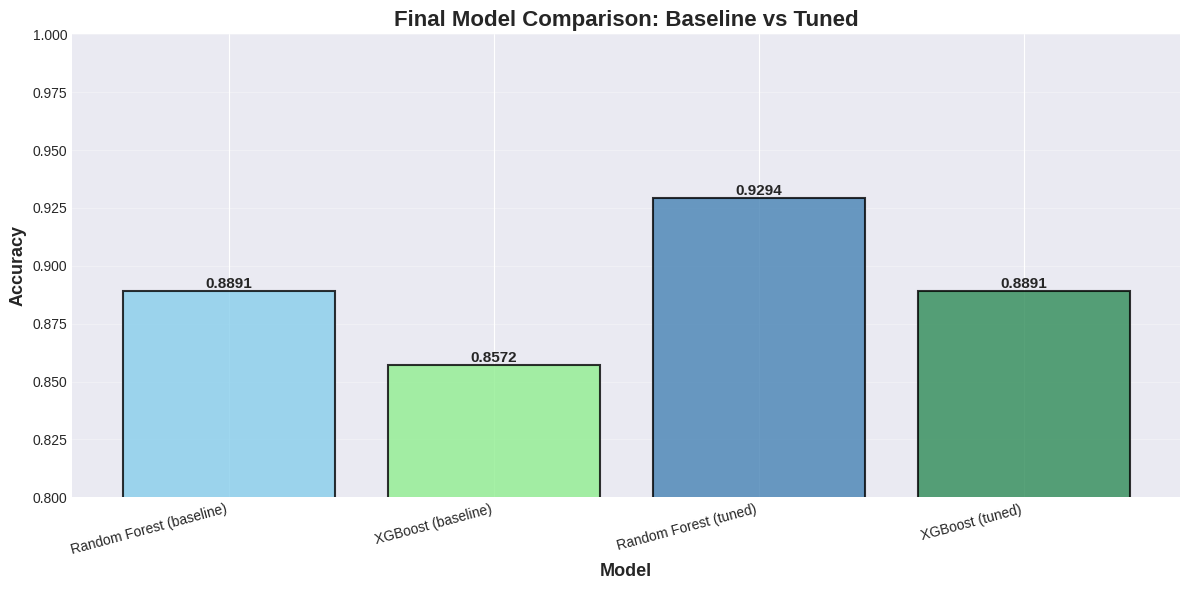

In [22]:
final_results = pd.DataFrame({
    'Model': [
        'Random Forest (baseline)',
        'XGBoost (baseline)',
        'Random Forest (tuned)',
        'XGBoost (tuned)'
    ],
    'Accuracy': [
        rf_accuracy,
        xgb_accuracy,
        rf_tuned_accuracy,
        xgb_tuned_accuracy
    ],
    'Accuracy %': [
        f"{rf_accuracy*100:.2f}%",
        f"{xgb_accuracy*100:.2f}%",
        f"{rf_tuned_accuracy*100:.2f}%",
        f"{xgb_tuned_accuracy*100:.2f}%"
    ]
})

print("FINAL RESULTS SUMMARY")
print(final_results.to_string(index=False))

best_idx = final_results['Accuracy'].idxmax()
best_model = final_results.loc[best_idx, 'Model']
best_acc = final_results.loc[best_idx, 'Accuracy']

print(f"\nBEST PERFORMING MODEL: {best_model}")
print(f"Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['skyblue', 'lightgreen', 'steelblue', 'seagreen']
bars = ax.bar(range(len(final_results)), final_results['Accuracy'],
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Final Model Comparison: Baseline vs Tuned', fontsize=16, fontweight='bold')
ax.set_xticks(range(len(final_results)))
ax.set_xticklabels(final_results['Model'], rotation=15, ha='right')
ax.set_ylim([0.80, 1.0])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
print("\nDataset:")
print(f"  • Total samples: {len(df):,}")
print(f"  • Features: {X.shape[1]}")
print(f"  • Classes: {len(y.unique())} forest cover types")
print(f"  • No missing values")

print("\n Model Performance:")
print(f"  • Both models achieved ~{rf_accuracy*100:.1f}% accuracy")
print(f"  • Hyperparameter tuning improved performance")
print(f"  • Best model: {best_model}")

print("\nImportant Features:")
print(f"  • Top RF feature: {feature_importance_rf.iloc[0]['feature']}")
print(f"  • Top XGB feature: {feature_importance_xgb.iloc[0]['feature']}")
print(f"  • Continuous features (elevation, distances) are most important")

print("\nTechniques Used:")
print("Multi-class classification (7 classes)")
print("Tree-based models (Random Forest & XGBoost)")
print("Feature scaling (StandardScaler)")
print("Stratified train-test split")
print("Confusion matrix analysis")
print("Feature importance ranking")
print("Hyperparameter tuning (GridSearchCV)")
print("Cross-validation (3-fold)")


Dataset:
  • Total samples: 581,012
  • Features: 54
  • Classes: 7 forest cover types
  • No missing values

 Model Performance:
  • Both models achieved ~88.9% accuracy
  • Hyperparameter tuning improved performance
  • Best model: Random Forest (tuned)

Important Features:
  • Top RF feature: Elevation
  • Top XGB feature: Elevation
  • Continuous features (elevation, distances) are most important

Techniques Used:
Multi-class classification (7 classes)
Tree-based models (Random Forest & XGBoost)
Feature scaling (StandardScaler)
Stratified train-test split
Confusion matrix analysis
Feature importance ranking
Hyperparameter tuning (GridSearchCV)
Cross-validation (3-fold)
